# TrustNote

Détection de contrefaçon de billet par analyse de données et apprentissage automatique.

Pour la présentation du contexte et du cas d'usage métier, voir le fichier `README.md` du dépôt `git`

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from sklearn.pipeline import Pipeline

import joblib

In [2]:
df = pd.read_csv('./data/fake_currency_data.csv')

In [3]:
df.head(5)

,Country,Denomination,Counterfeit,SerialNumber,SecurityFeatures,Weight,Length,Width,Thickness
0,USA,$100,1,25973198,Hologram,1.731759,130.243185,66.537999,0.098488
1,USA,$20,1,95903230,Security Thread,1.002179,152.596364,76.135834,0.094119
2,EU,€10,0,82937914,Hologram,2.306713,152.857126,66.772442,0.061393
3,USA,€20,1,23612989,Microprint,1.366965,143.133672,78.377052,0.053114
4,EU,€20,1,56025342,Watermark,1.796075,129.664777,75.916093,0.051438


Affichage des 5 premières lignes du dataset.

Nous avons les variables suivantes :
- country : permet de définir le pays du billet (USA, EU, UK) ;
- denomination : permet de savoir s'il s'agit d'un billet de 20€, de 5$, ... ;
- counterfeit : la variable "label", permettant de dire s'il s'agit d'un billet contrefait ou non ;
- serialnumber : numéro de série du billet
- securityFeatures : technologie de sécurité
- weight : le poids du billet
- length : la longueur du billet
- width : la largeur du billet
- thickness : l'épaisseur du billet

## Structure des données

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 9 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Country           1000000 non-null  str    
 1   Denomination      1000000 non-null  str    
 2   Counterfeit       1000000 non-null  int64  
 3   SerialNumber      1000000 non-null  int64  
 4   SecurityFeatures  1000000 non-null  str    
 5   Weight            1000000 non-null  float64
 6   Length            1000000 non-null  float64
 7   Width             1000000 non-null  float64
 8   Thickness         1000000 non-null  float64
dtypes: float64(4), int64(2), str(3)
memory usage: 68.7 MB


Nous avons 1000000 de lignes dans ce dataset.

- les variables `weight`, `length`, `width` et `thickness` sont des variables quantitative (numérique) ;
- les variables `country` et `denomination` sont des variables qualitatives (des catégories).

In [5]:
df = df.rename(columns={
    "Country": "country",
    "Denomination": "denomination",
    "Counterfeit": "counterfeit",
    "SerialNumber": "serial_number",
    "SecurityFeatures": "security_features",
    "Weight": "weight",
    "Length": "length",
    "Width": "width",
    "Thickness": "thickness"
})

df.sample(n=5)

,country,denomination,counterfeit,serial_number,security_features,weight,length,width,thickness
533281,USA,$50,1,59117288,Security Thread,1.774851,137.688795,72.923935,0.056384
761668,UK,$5,0,47665598,Watermark,1.740462,148.832262,61.747384,0.089041
86727,USA,$5,1,59778529,Microprint,2.368502,147.509807,69.400422,0.068141
687504,USA,$100,1,78386427,Security Thread,1.217486,144.968325,75.746365,0.061827
293465,UK,£10,1,38701678,Hologram,0.884350,147.124505,72.648535,0.093060


Renommage des variables pour avoir des minuscules.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 9 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   country            1000000 non-null  str    
 1   denomination       1000000 non-null  str    
 2   counterfeit        1000000 non-null  int64  
 3   serial_number      1000000 non-null  int64  
 4   security_features  1000000 non-null  str    
 5   weight             1000000 non-null  float64
 6   length             1000000 non-null  float64
 7   width              1000000 non-null  float64
 8   thickness          1000000 non-null  float64
dtypes: float64(4), int64(2), str(3)
memory usage: 68.7 MB


Nous n'avons **aucunes données manquantes.**

Regardons les répartitions de données des variables qualitatives :

<Axes: xlabel='country'>

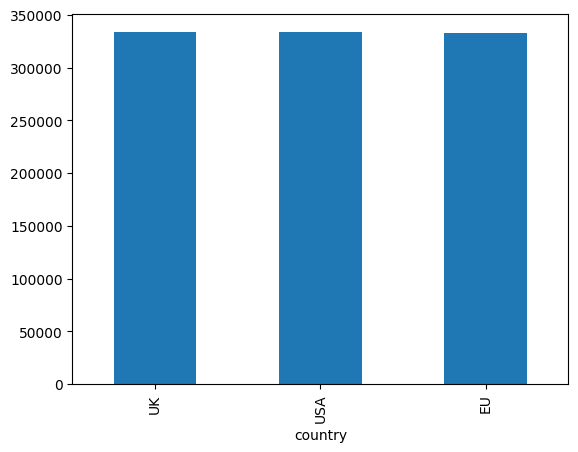

In [7]:
df['country'].value_counts().plot.bar()

<Axes: xlabel='denomination'>

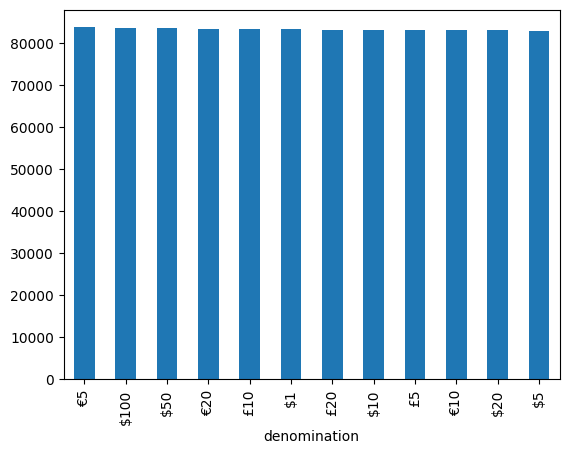

In [8]:
df['denomination'].value_counts().plot.bar()

Nous avons donc trois pays : USA, UK, EU et **douze types de billets différents**

In [9]:
cross_tab = pd.crosstab(index=df["country"], columns=df["denomination"])
cross_tab

denomination,$1,$10,$100,$20,$5,$50,£10,£20,£5,€10,€20,€5
country,,,,,,,,,,,,
EU,27749,27771,27678,27356,27431,27789,27923,27892,27707,27718,27896,28141
UK,28043,27644,28030,27810,27825,27821,27791,27694,27609,27689,27777,27878
USA,27554,27817,27904,27895,27612,27983,27718,27656,27876,27752,27821,27750


Ce tableau croisé montre que les deux variables précédentes n'ont pas de lien : nous pouvons avoir des billets de `5$` dans le country `EU`

<Axes: xlabel='security_features'>

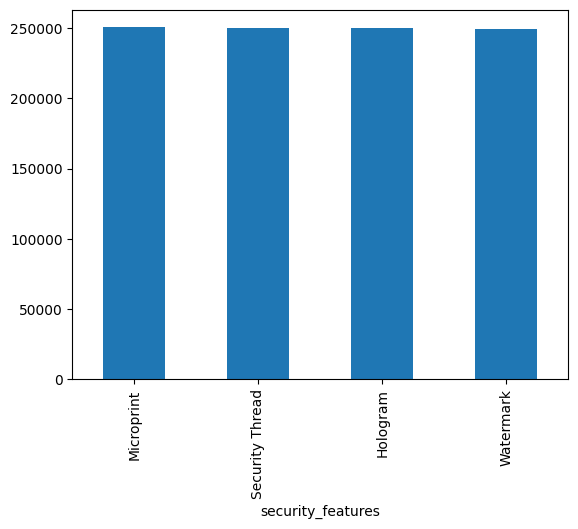

In [10]:
df['security_features'].value_counts().plot.bar()

In [11]:
df['security_features'].value_counts()

security_features
Microprint         250365
Security Thread    250208
Hologram           250046
Watermark          249381
Name: count, dtype: int64

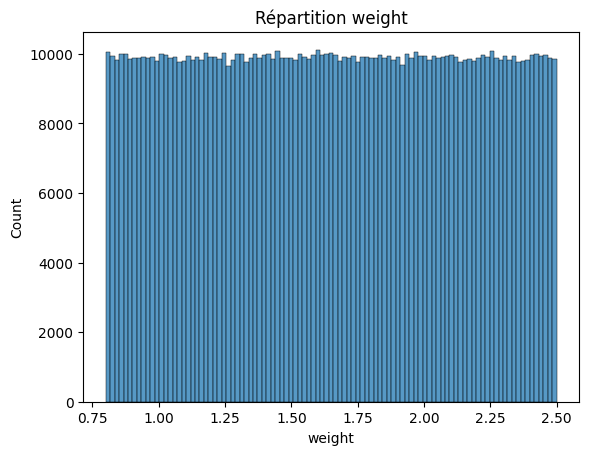

In [12]:
plt.figure()
sns.histplot(data=df["weight"])
plt.title(f"Répartition weight")
plt.show()

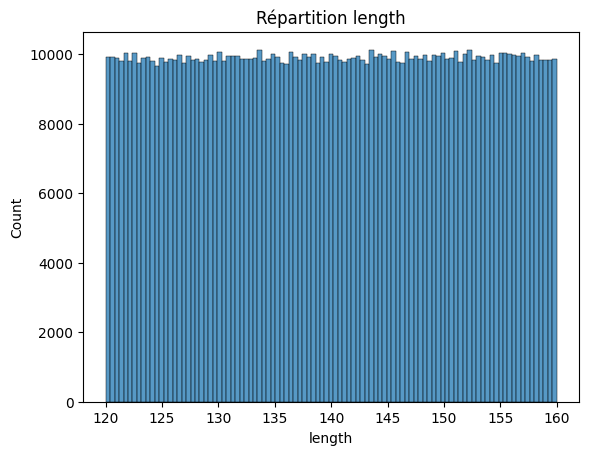

In [13]:
plt.figure()
sns.histplot(data=df["length"])
plt.title(f"Répartition length")
plt.show()

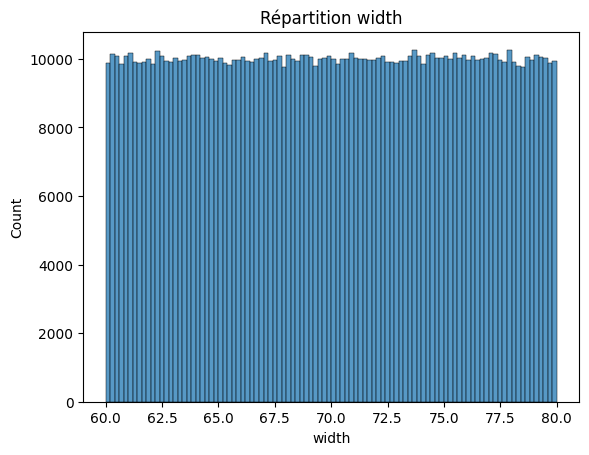

In [14]:
plt.figure()
sns.histplot(data=df["width"])
plt.title(f"Répartition width")
plt.show()

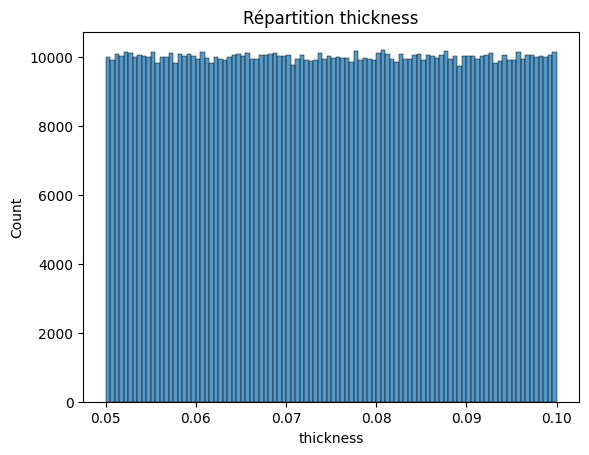

In [15]:
plt.figure()
sns.histplot(data=df["thickness"])
plt.title(f"Répartition thickness")
plt.show()

les données `weight`, `length`, `width` et `thickness` sont réparties de manière homogènes. Les distributions semblent uniformes.

In [16]:
df.describe(include="all")

,country,denomination,counterfeit,serial_number,security_features,weight,length,width,thickness
count,1000000,1000000,1000000.000000,1.000000e+06,1000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
unique,3,12,NaN,NaN,4,NaN,NaN,NaN,NaN
top,UK,€5,NaN,NaN,Microprint,NaN,NaN,NaN,NaN
freq,333611,83769,NaN,NaN,250365,NaN,NaN,NaN,NaN
mean,NaN,NaN,0.499391,5.502259e+07,NaN,1.649766,140.020542,70.003944,0.074995
std,NaN,NaN,0.500000,2.598490e+07,NaN,0.490712,11.544293,5.772709,0.014442
min,NaN,NaN,0.000000,1.000015e+07,NaN,0.800003,120.000073,60.000005,0.050000
25%,NaN,NaN,0.000000,3.249784e+07,NaN,1.224855,130.034878,64.999762,0.062487
50%,NaN,NaN,0.000000,5.506594e+07,NaN,1.649137,140.032496,70.008440,0.074992
75%,NaN,NaN,1.000000,7.751115e+07,NaN,2.074540,150.022309,75.006372,0.087499


### Analyse du label

L'analyse du label est nécessaire, notamment pour la partie algo supervisé.

<Axes: xlabel='counterfeit'>

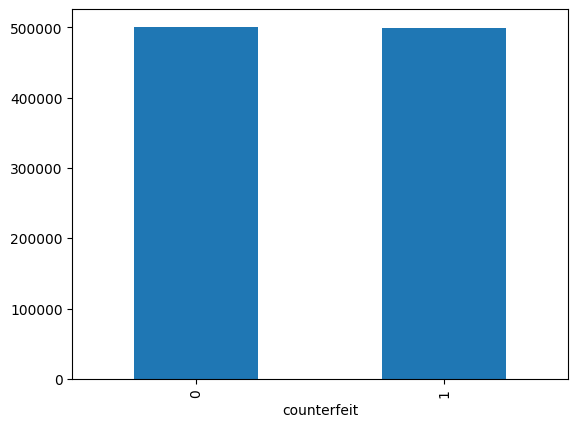

In [68]:
df["counterfeit"].value_counts().plot.bar()

Nous avons autant de vrai billets que de faux.

## Détecter les problèmes dans les données



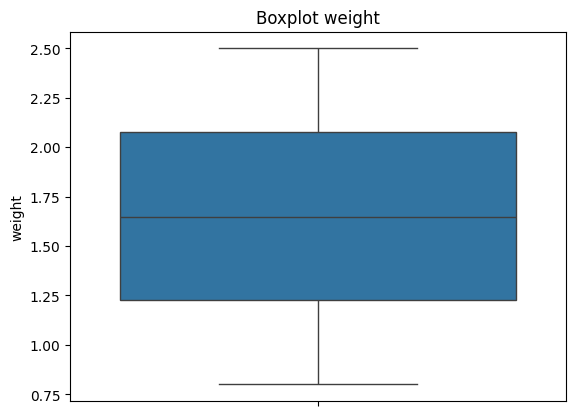

In [17]:
plt.figure()
sns.boxplot(data=df["weight"])
plt.title(f"Boxplot weight")
plt.show()

le boxplot de weight montre une distribution homogène du poids des billets, sans outliers.

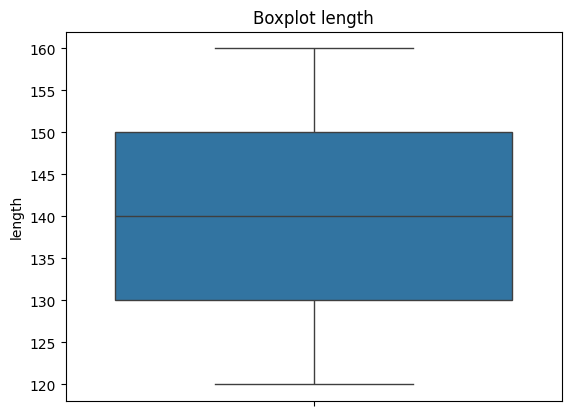

In [18]:
plt.figure()
sns.boxplot(data=df["length"])
plt.title(f"Boxplot length")
plt.show()

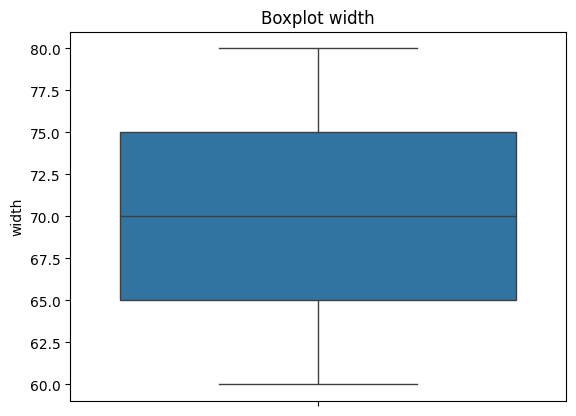

In [19]:
plt.figure()
sns.boxplot(data=df["width"])
plt.title(f"Boxplot width")
plt.show()

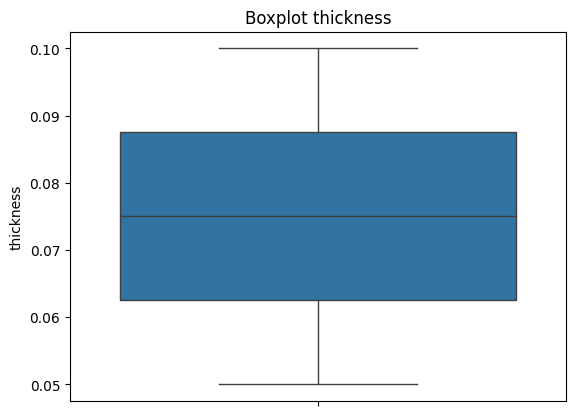

In [20]:
plt.figure()
sns.boxplot(data=df["thickness"])
plt.title(f"Boxplot thickness")
plt.show()

L'ensemble des boxplots `weigth`, `length`, `width` et `thickness` montrent une répartition des données homogène, sans outliers.

## Analyse et corrélations

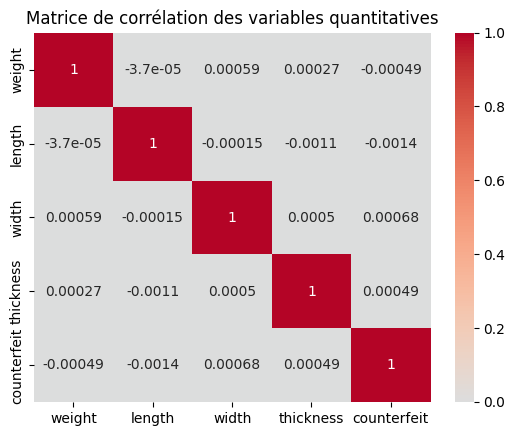

In [21]:
plt.figure()
sns.heatmap(df[["weight", "length", "width", "thickness", "counterfeit"]].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Matrice de corrélation des variables quantitatives")
plt.show()

il ne semble pas y'avoir de correlations simples entre les variables quantitatives.

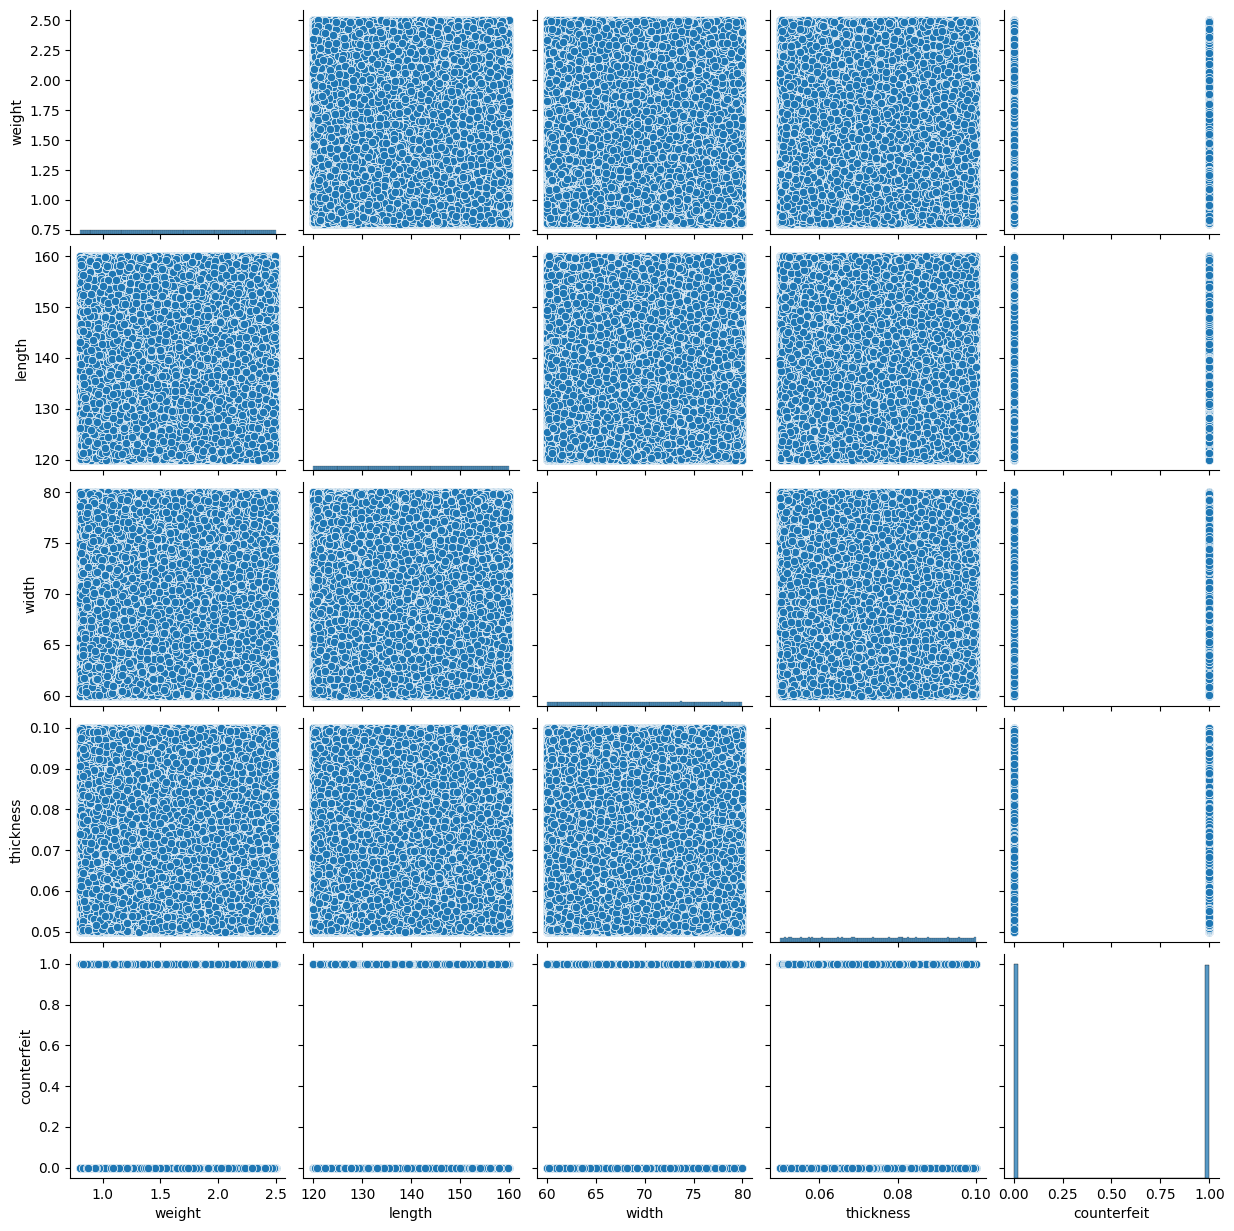

In [22]:
sns.pairplot(df[["weight", "length", "width", "thickness", "counterfeit"]])
plt.show()

Il n'y a aucun pattern pertinent dans le scatterplot, les correlations entre les variables sont nulles et nous ne parvenons pas à distinguer d'éventuels clusters simples.

## modélisation

### Choix des variables

nous allons selectionner les variables suivantes pour nos modèles :

| variable          | commentaire                                            |
| ----------------- | ------------------------------------------------------ |
| country           | Feature. Traitement en one hot encoding (3 modalités)  |
| denomination      | Feature. Traitement en one hot encoding (12 modalités) |
| counterfeit       | Label - variables à prédire                            |
| security_features | Feature. Traitement en one hot encoding (4 modalités)  |
| weight            | Feature, quantitative                                  |
| length            | Feature, quantitative                                  |
| width             | Feature, quantitative                                  |
| thickness         | Feature, quantitative                                  |

la variable `serialnumber` est exclue car elle n'apportera aucune information.

Les variables country, denomination et security_features apportent beaucoup de dimension en one-hot encoding, mais cela est necessaire en première approche.

Cela fera au total 23 dimensions, nous affinerons peut être ce choix si nous nous rendons compte qu'il y a trop de dimensions.

In [26]:
df2 = df.drop(columns='serial_number')

df2

,country,denomination,counterfeit,security_features,weight,length,width,thickness
0,USA,$100,1,Hologram,1.731759,130.243185,66.537999,0.098488
1,USA,$20,1,Security Thread,1.002179,152.596364,76.135834,0.094119
2,EU,€10,0,Hologram,2.306713,152.857126,66.772442,0.061393
3,USA,€20,1,Microprint,1.366965,143.133672,78.377052,0.053114
4,EU,€20,1,Watermark,1.796075,129.664777,75.916093,0.051438
...,...,...,...,...,...,...,...,...
999995,EU,$100,1,Watermark,1.472511,134.888731,75.425943,0.093939
999996,EU,£20,1,Hologram,2.355633,147.830149,65.232274,0.097358
999997,USA,$5,0,Microprint,1.393764,150.050308,69.273269,0.068363
999998,EU,£10,0,Watermark,2.026417,142.852137,77.878841,0.081160


In [27]:
variables_quantitatives = ["weight", "length", "width", "thickness"]
variables_qualitatives = ["country", "denomination", "security_features"]
label = ["counterfeit"]

### Traitement des variables en `one-hot`

In [43]:
# le processor pour l'encodage en one_hot

preprocessor_one_hot = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                drop=None,
                handle_unknown="ignore",
                sparse_output=False,
            ),
            variables_qualitatives,
        )
    ],
    # remainder="passthrough"
    remainder="drop",
)

# encodage
X = df2[variables_qualitatives]

X_encoded = preprocessor_one_hot.fit_transform(X)

# nom des features suite au one_hot
variables_one_hot = preprocessor_one_hot.named_transformers_[
    "cat"
].get_feature_names_out(variables_qualitatives)
variables_one_hot = list(variables_one_hot)

# création du DF à partir des données encodées

df_one_hot = pd.DataFrame(X_encoded, columns=variables_one_hot)

df_one_hot

,country_EU,country_UK,country_USA,denomination_$1,denomination_$10,denomination_$100,denomination_$20,denomination_$5,denomination_$50,denomination_£10,denomination_£20,denomination_£5,denomination_€10,denomination_€20,denomination_€5,security_features_Hologram,security_features_Microprint,security_features_Security Thread,security_features_Watermark
0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
999996,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
999997,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
999998,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


le dataframe avec les one-hot encoding. Nous avons bien **19 colonnes de features** suit à cet encoding one hot.

### Traitement des variables quantitatives

nous allons normaliser les valeurs des variables quantitatives.

In [120]:
variables_quantitatives

['weight', 'length', 'width', 'thickness']

In [44]:
# le processor pour la normalisation des variables quantitatives

preprocessor_standard = ColumnTransformer(
    transformers=[("num", StandardScaler(), variables_quantitatives)],
    remainder="drop",
)

# encodage
X = df2[variables_quantitatives]

X_encoded = preprocessor_standard.fit_transform(X)

# création du DF à partir des données encodées

df_quantitatif = pd.DataFrame(
    X_encoded, columns=variables_quantitatives
)

df_quantitatif

,weight,length,width,thickness
0,0.167090,-0.846943,-0.600402,1.626770
1,-1.319690,1.089354,1.062221,1.324222
2,1.338762,1.111942,-0.559790,-0.941893
3,-0.576307,0.269668,1.450465,-1.515130
4,0.298157,-0.897047,1.024156,-1.631179
...,...,...,...,...
999995,-0.361220,-0.444533,0.939247,1.311788
999996,1.438456,0.676491,-0.826592,1.548485
999997,-0.521696,0.868808,-0.126574,-0.459211
999998,0.767559,0.245281,1.364160,0.426876


### DataFrame Final

In [45]:
df_final = pd.concat([
    df_quantitatif, df_one_hot, df["counterfeit"]
], axis=1)

df_final

,weight,length,width,thickness,country_EU,country_UK,country_USA,denomination_$1,denomination_$10,denomination_$100,...,denomination_£20,denomination_£5,denomination_€10,denomination_€20,denomination_€5,security_features_Hologram,security_features_Microprint,security_features_Security Thread,security_features_Watermark,counterfeit
0,0.167090,-0.846943,-0.600402,1.626770,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
1,-1.319690,1.089354,1.062221,1.324222,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
2,1.338762,1.111942,-0.559790,-0.941893,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0
3,-0.576307,0.269668,1.450465,-1.515130,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1
4,0.298157,-0.897047,1.024156,-1.631179,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,-0.361220,-0.444533,0.939247,1.311788,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
999996,1.438456,0.676491,-0.826592,1.548485,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
999997,-0.521696,0.868808,-0.126574,-0.459211,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
999998,0.767559,0.245281,1.364160,0.426876,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0


Notre dataframe final comprends bien les 23 dimensions (4 pour les variables quantitatives, et 19 qualitatives) + le label.

## Modèle non supervisé

Nous allons appliquer l'algorithme KMeans. C'est un algorithme non supervisé très performant même avec beaucoup de dimensions.

Cela aboutira à un clustering, qui nous permettras de comprendre les "profils" de billets que nous avons.

Pour ce clustering, nous n'allons pas utiliser la variable `counterfeit` (puisque cela n'a pas de sens en non supervisé)

In [50]:
df_features_only = df_final.drop(columns="counterfeit")

df_features_only

,weight,length,width,thickness,country_EU,country_UK,country_USA,denomination_$1,denomination_$10,denomination_$100,...,denomination_£10,denomination_£20,denomination_£5,denomination_€10,denomination_€20,denomination_€5,security_features_Hologram,security_features_Microprint,security_features_Security Thread,security_features_Watermark
0,0.167090,-0.846943,-0.600402,1.626770,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-1.319690,1.089354,1.062221,1.324222,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1.338762,1.111942,-0.559790,-0.941893,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,-0.576307,0.269668,1.450465,-1.515130,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0.298157,-0.897047,1.024156,-1.631179,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,-0.361220,-0.444533,0.939247,1.311788,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
999996,1.438456,0.676491,-0.826592,1.548485,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
999997,-0.521696,0.868808,-0.126574,-0.459211,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
999998,0.767559,0.245281,1.364160,0.426876,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


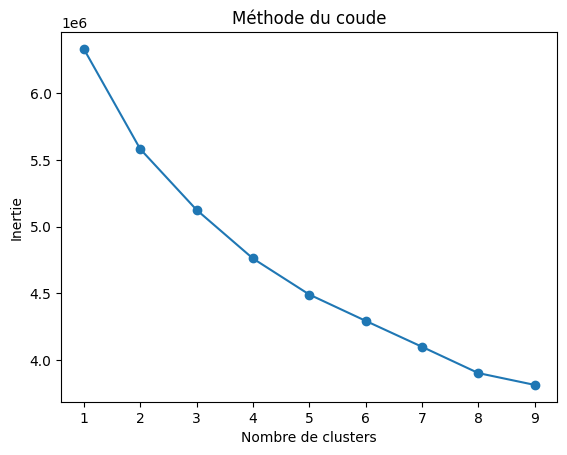

In [ ]:
# nous allons appliquer la méthode du coude, pour trouver le nombre de cluster optimal (celui qui réduit l'intertie sans avoir un nombre trop élevé de clusters)

inertias = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_features_only)
    inertias.append(kmeans.inertia_)

plt.plot(range(1, 10), inertias, marker="o")
plt.title("Méthode du coude")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")
plt.show()

la méthode du coude ne fonctionne pas très bien ici pour trouver le nombre de clusters.

Nous allons donc faire la méthode de la silhouette.

on teste avec k = 2
cluster calculé
Pour 2 clusters, le Silhouette Score est : 0.113
on teste avec k = 3
cluster calculé
Pour 3 clusters, le Silhouette Score est : 0.099
on teste avec k = 4
cluster calculé
Pour 4 clusters, le Silhouette Score est : 0.102
on teste avec k = 5
cluster calculé
Pour 5 clusters, le Silhouette Score est : 0.103
on teste avec k = 6
cluster calculé
Pour 6 clusters, le Silhouette Score est : 0.099
on teste avec k = 7
cluster calculé
Pour 7 clusters, le Silhouette Score est : 0.102


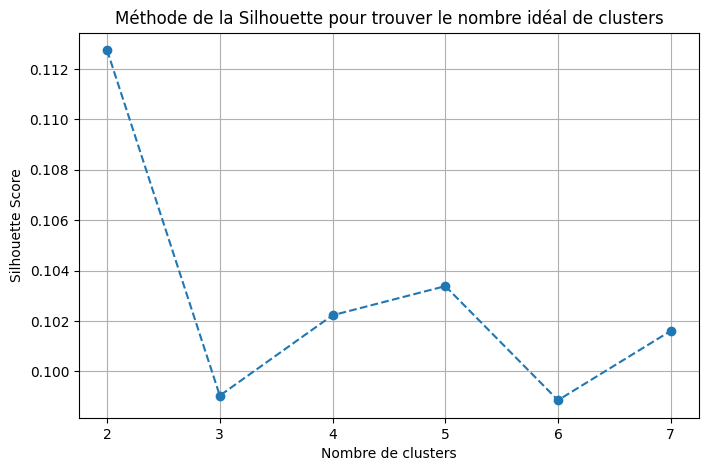

In [ ]:
silhouette_scores = []

k_values = list(range(2, 8))

df_sample = df_features_only.sample(n=50000)

X = df_sample

for k in k_values:
    print(f"on teste avec k = {k}")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)
    print("cluster calculé")
    silhouette_avg = silhouette_score(X, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"Pour {k} clusters, le Silhouette Score est : {silhouette_avg:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o", linestyle="--")
plt.xlabel("Nombre de clusters")
plt.ylabel("Silhouette Score")
plt.title("Méthode de la Silhouette pour trouver le nombre idéal de clusters")
plt.grid(True)
plt.show()

Nous choisissons donc **k = 2**

In [58]:
k = 2

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_features_only)

df_kmeans = df_final.copy()
df_kmeans["cluster"] = clusters

df_kmeans

,weight,length,width,thickness,country_EU,country_UK,country_USA,denomination_$1,denomination_$10,denomination_$100,...,denomination_£5,denomination_€10,denomination_€20,denomination_€5,security_features_Hologram,security_features_Microprint,security_features_Security Thread,security_features_Watermark,counterfeit,cluster
0,0.167090,-0.846943,-0.600402,1.626770,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,1
1,-1.319690,1.089354,1.062221,1.324222,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
2,1.338762,1.111942,-0.559790,-0.941893,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0
3,-0.576307,0.269668,1.450465,-1.515130,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1,0
4,0.298157,-0.897047,1.024156,-1.631179,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,-0.361220,-0.444533,0.939247,1.311788,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,1
999996,1.438456,0.676491,-0.826592,1.548485,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,1
999997,-0.521696,0.868808,-0.126574,-0.459211,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0
999998,0.767559,0.245281,1.364160,0.426876,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,1


### visualisation des clusters

Nous allons réduire les dimensions avec une PCA (Principal component analysis) afin d'afficher de manière graphique le résultat du clustering.

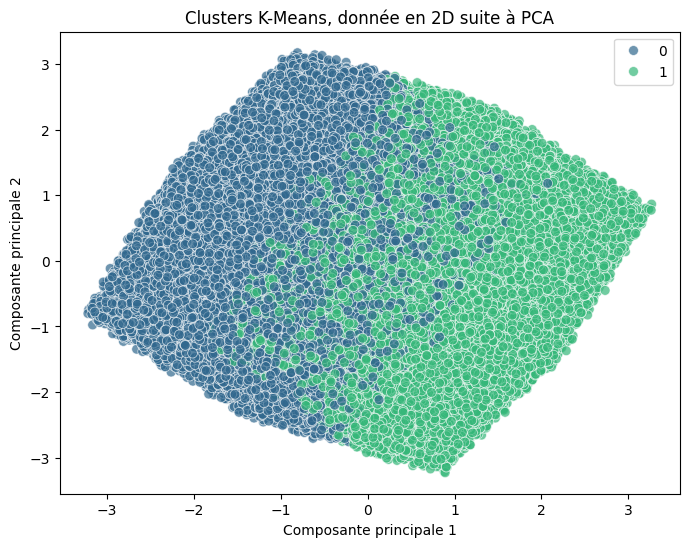

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_features_only)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette="viridis", s=50, alpha=0.7)
plt.title(f"Clusters K-Means, donnée en 2D suite à PCA")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.show()

Analysons maintenant si les clusters sont indicatifs par rapport à notre variable `counterfeit`

In [80]:
# cluster_counterfeit_rate = df_kmeans.groupby("cluster")["counterfeit"].mean()

# cluster_counterfeit_rate

df_kmeans[["cluster", "counterfeit"]].value_counts()

cluster  counterfeit
0        0              250542
1        0              250067
         1              249900
0        1              249491
Name: count, dtype: int64

Non, au sein de nos clusters nous n'avons pas plus d'informations sur le fait de savoir si un billet est contrefait ou pas.

Le modèle non supervisé ne va donc pas nous aider à prédire s'il s'agit d'un vrai ou d'un faux billet. Mais comme nous avons des données labelisées, nous allons pouvoir entraîner un modèle supervisé.

### sauvegarde du modèle

Nous allons sauvegarder le **modèle non supervisé** au format `pickle`. Nous allons d'abord regrouper tout le traitement dans un unique traitement.

In [95]:
# on regroupe tout le traitement dans un pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(drop=None, handle_unknown="ignore"),
            variables_qualitatives,
        ),
        ("num", StandardScaler(), variables_quantitatives),
    ],
    remainder="drop",
)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

pipeline_non_supervise = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("kmeans", kmeans),
    ]
)

# application sur les données

X = df[variables_qualitatives + variables_quantitatives]

pipeline_non_supervise.fit(X)

# résultat

df_test = df[variables_qualitatives + variables_quantitatives + ["counterfeit"]]

df_test["cluster"] = pipeline_non_supervise.named_steps["kmeans"].labels_

df_test[["cluster", "counterfeit"]].value_counts()


cluster  counterfeit
0        0              250542
1        0              250067
         1              249900
0        1              249491
Name: count, dtype: int64

In [97]:
# sauvegarde du pipeline

joblib.dump(pipeline_non_supervise, './models/non_supervie.pkl')

['./models/non_supervie.pkl']